In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import accuracy_score
from utils import utils_ml 

from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.feature_selection import VarianceThreshold

In [2]:
import glob
import pickle

# Get all matching files
files = glob.glob("fold_accuracies*.pkl")

# Separate files into raw and normal
raw_files = [f for f in files if "raw" in f]
normal_files = [f for f in files if "raw" not in f]

# Load the data
raw_data = [pickle.load(open(f, "rb")) for f in raw_files]
normal_data = [pickle.load(open(f, "rb")) for f in normal_files]


In [3]:
len(normal_data)

5

In [4]:

feat_to_per_dict = {}
feature_percentages = np.logspace(-2, 0, 5)[:-1]  # From 1% to 100% of features
feature_counts = np.unique(
    np.clip((feature_percentages * 75).astype(int), 1, 75)
)
feat_to_per_dict = {int(feat): per for feat, per in zip(feature_counts, feature_percentages)}
feat_to_per_dict


{1: 0.01,
 2: 0.03162277660168379,
 7: 0.09999999999999999,
 23: 0.31622776601683794}

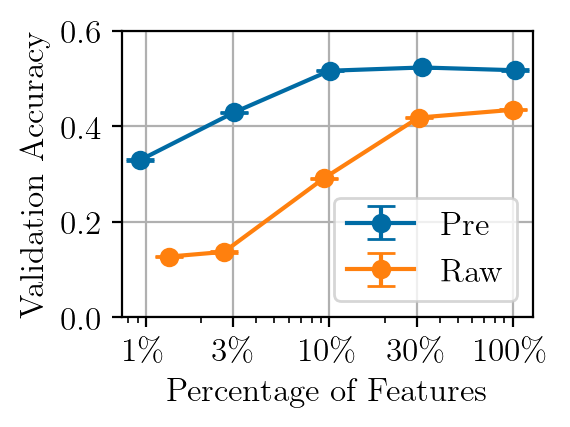

In [5]:
def get_stats(data):
    feature_counts = []
    accuracy_lists = []

    for item in data:
        for count, accuracies in item.items():
            feature_counts.append(count)
            accuracy_lists.append(accuracies)

    # Sort data by feature count
    sorted_indices = np.argsort(feature_counts)
    feature_counts = [feature_counts[i] for i in sorted_indices]
    accuracy_lists = [accuracy_lists[i] for i in sorted_indices]

    # Calculate means and standard deviations
    means = [np.mean(accuracies) for accuracies in accuracy_lists]
    stds = [np.std(accuracies) for accuracies in accuracy_lists]

    return means, stds, feature_counts

means_r, stds_r, feature_counts_r = get_stats(raw_data)
means_n, stds_n, feature_counts_n = get_stats(normal_data)

# Create the plot
plt.figure(figsize=(3, 2.3))
plt.errorbar(100 * np.array(feature_counts_n) / 429, means_n, yerr=stds_n, fmt='-o', capsize=5,label="Pre")
plt.errorbar(100 * np.array(feature_counts_r) / 75, means_r, yerr=stds_r, fmt='-o', capsize=5,label="Raw")
plt.xscale('log')
plt.xticks([1, 3, 10, 30, 100], labels=["1\%", "3\%", "10\%", "30\%", "100\%"])
plt.xlabel("Percentage of Features")
plt.ylabel("Validation Accuracy")
# plt.title("Effect of Feature Count on Accuracy")
plt.grid(True)
plt.ylim(0,0.6)
plt.tight_layout()
plt.legend()
plt.show()